In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

In [3]:
df = pd.read_csv('insurance_claims.csv')
df

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,?,87200,17440,8720,61040,Honda,Accord,2006,N,NaN
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,?,108480,18080,18080,72320,Volkswagen,Passat,2015,N,NaN
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,YES,67500,7500,7500,52500,Suburu,Impreza,1996,N,NaN
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,YES,46980,5220,5220,36540,Audi,A5,1998,N,NaN


In [4]:
df.replace('?', np.nan, inplace = True)


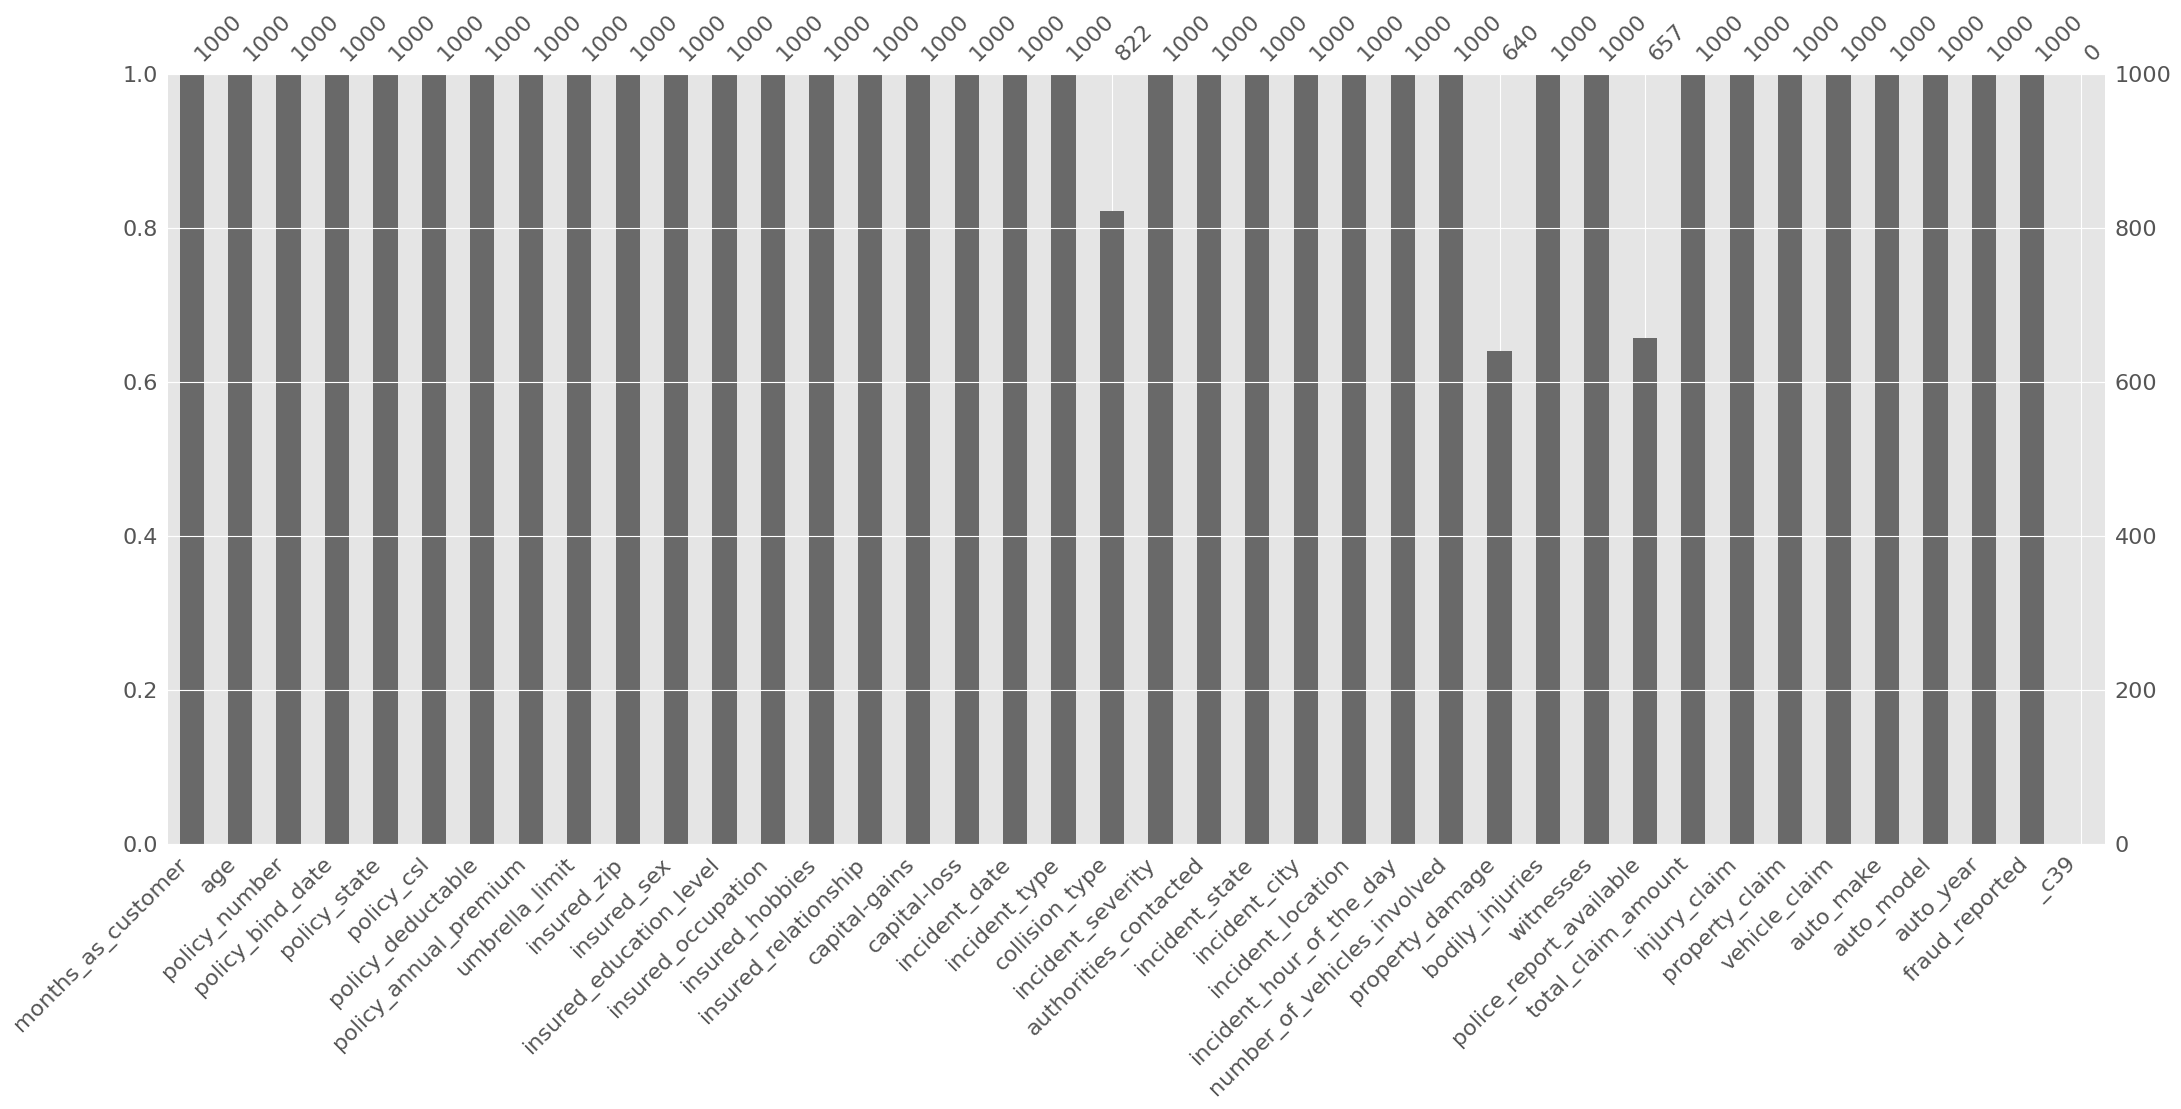

In [5]:
import missingno as msno

msno.bar(df)
plt.show()

In [6]:
df['collision_type'] = df['collision_type'].fillna(df['collision_type'].mode()[0])

In [7]:
df['property_damage'] = df['property_damage'].fillna(df['property_damage'].mode()[0])

In [8]:
df['police_report_available'] = df['police_report_available'].fillna(df['police_report_available'].mode()[0])

In [9]:
to_drop = ['policy_number','policy_bind_date','policy_state','insured_zip','incident_location','incident_date',
           'incident_state','incident_city','insured_hobbies','auto_make','auto_model','auto_year', '_c39']

df.drop(to_drop, inplace = True, axis = 1)

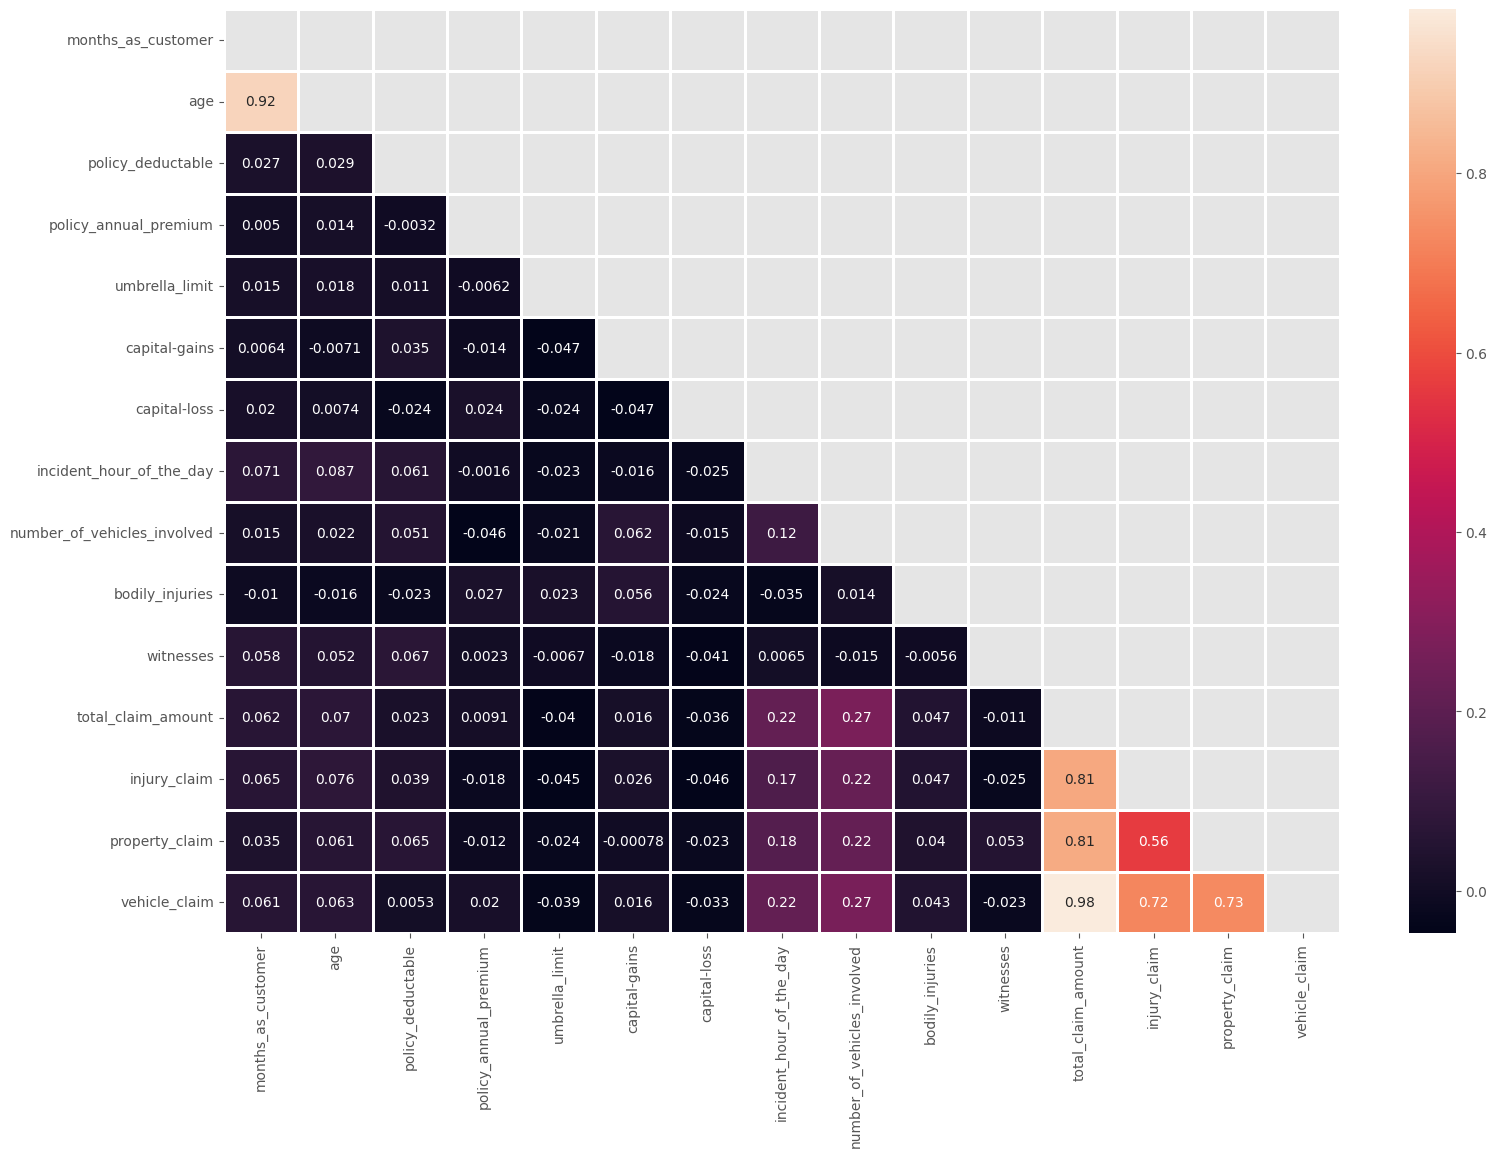

In [10]:
plt.figure(figsize = (18, 12))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype = bool))

sns.heatmap(data = corr, mask = mask, annot = True, fmt = '.2g', linewidth = 1)
plt.show()

In [11]:
df.drop(columns = ['age', 'total_claim_amount'], inplace = True, axis = 1)


In [12]:
X = df.drop('fraud_reported', axis = 1)
y = df['fraud_reported']

In [13]:
cat_df = X.select_dtypes(include = ['object'])


In [14]:
# printing unique values of each column
for col in cat_df.columns:
    print(f"{col}: \n{cat_df[col].unique()}\n")

policy_csl: 
['250/500' '100/300' '500/1000']

insured_sex: 
['MALE' 'FEMALE']

insured_education_level: 
['MD' 'PhD' 'Associate' 'Masters' 'High School' 'College' 'JD']

insured_occupation: 
['craft-repair' 'machine-op-inspct' 'sales' 'armed-forces' 'tech-support'
 'prof-specialty' 'other-service' 'priv-house-serv' 'exec-managerial'
 'protective-serv' 'transport-moving' 'handlers-cleaners' 'adm-clerical'
 'farming-fishing']

insured_relationship: 
['husband' 'other-relative' 'own-child' 'unmarried' 'wife' 'not-in-family']

incident_type: 
['Single Vehicle Collision' 'Vehicle Theft' 'Multi-vehicle Collision'
 'Parked Car']

collision_type: 
['Side Collision' 'Rear Collision' 'Front Collision']

incident_severity: 
['Major Damage' 'Minor Damage' 'Total Loss' 'Trivial Damage']

authorities_contacted: 
['Police' 'None' 'Fire' 'Other' 'Ambulance']

property_damage: 
['YES' 'NO']

police_report_available: 
['YES' 'NO']



In [15]:
cat_df = pd.get_dummies(cat_df, drop_first = True)


In [16]:
num_df = X.select_dtypes(include = ['int64'])


In [17]:
X = pd.concat([num_df, cat_df], axis = 1)


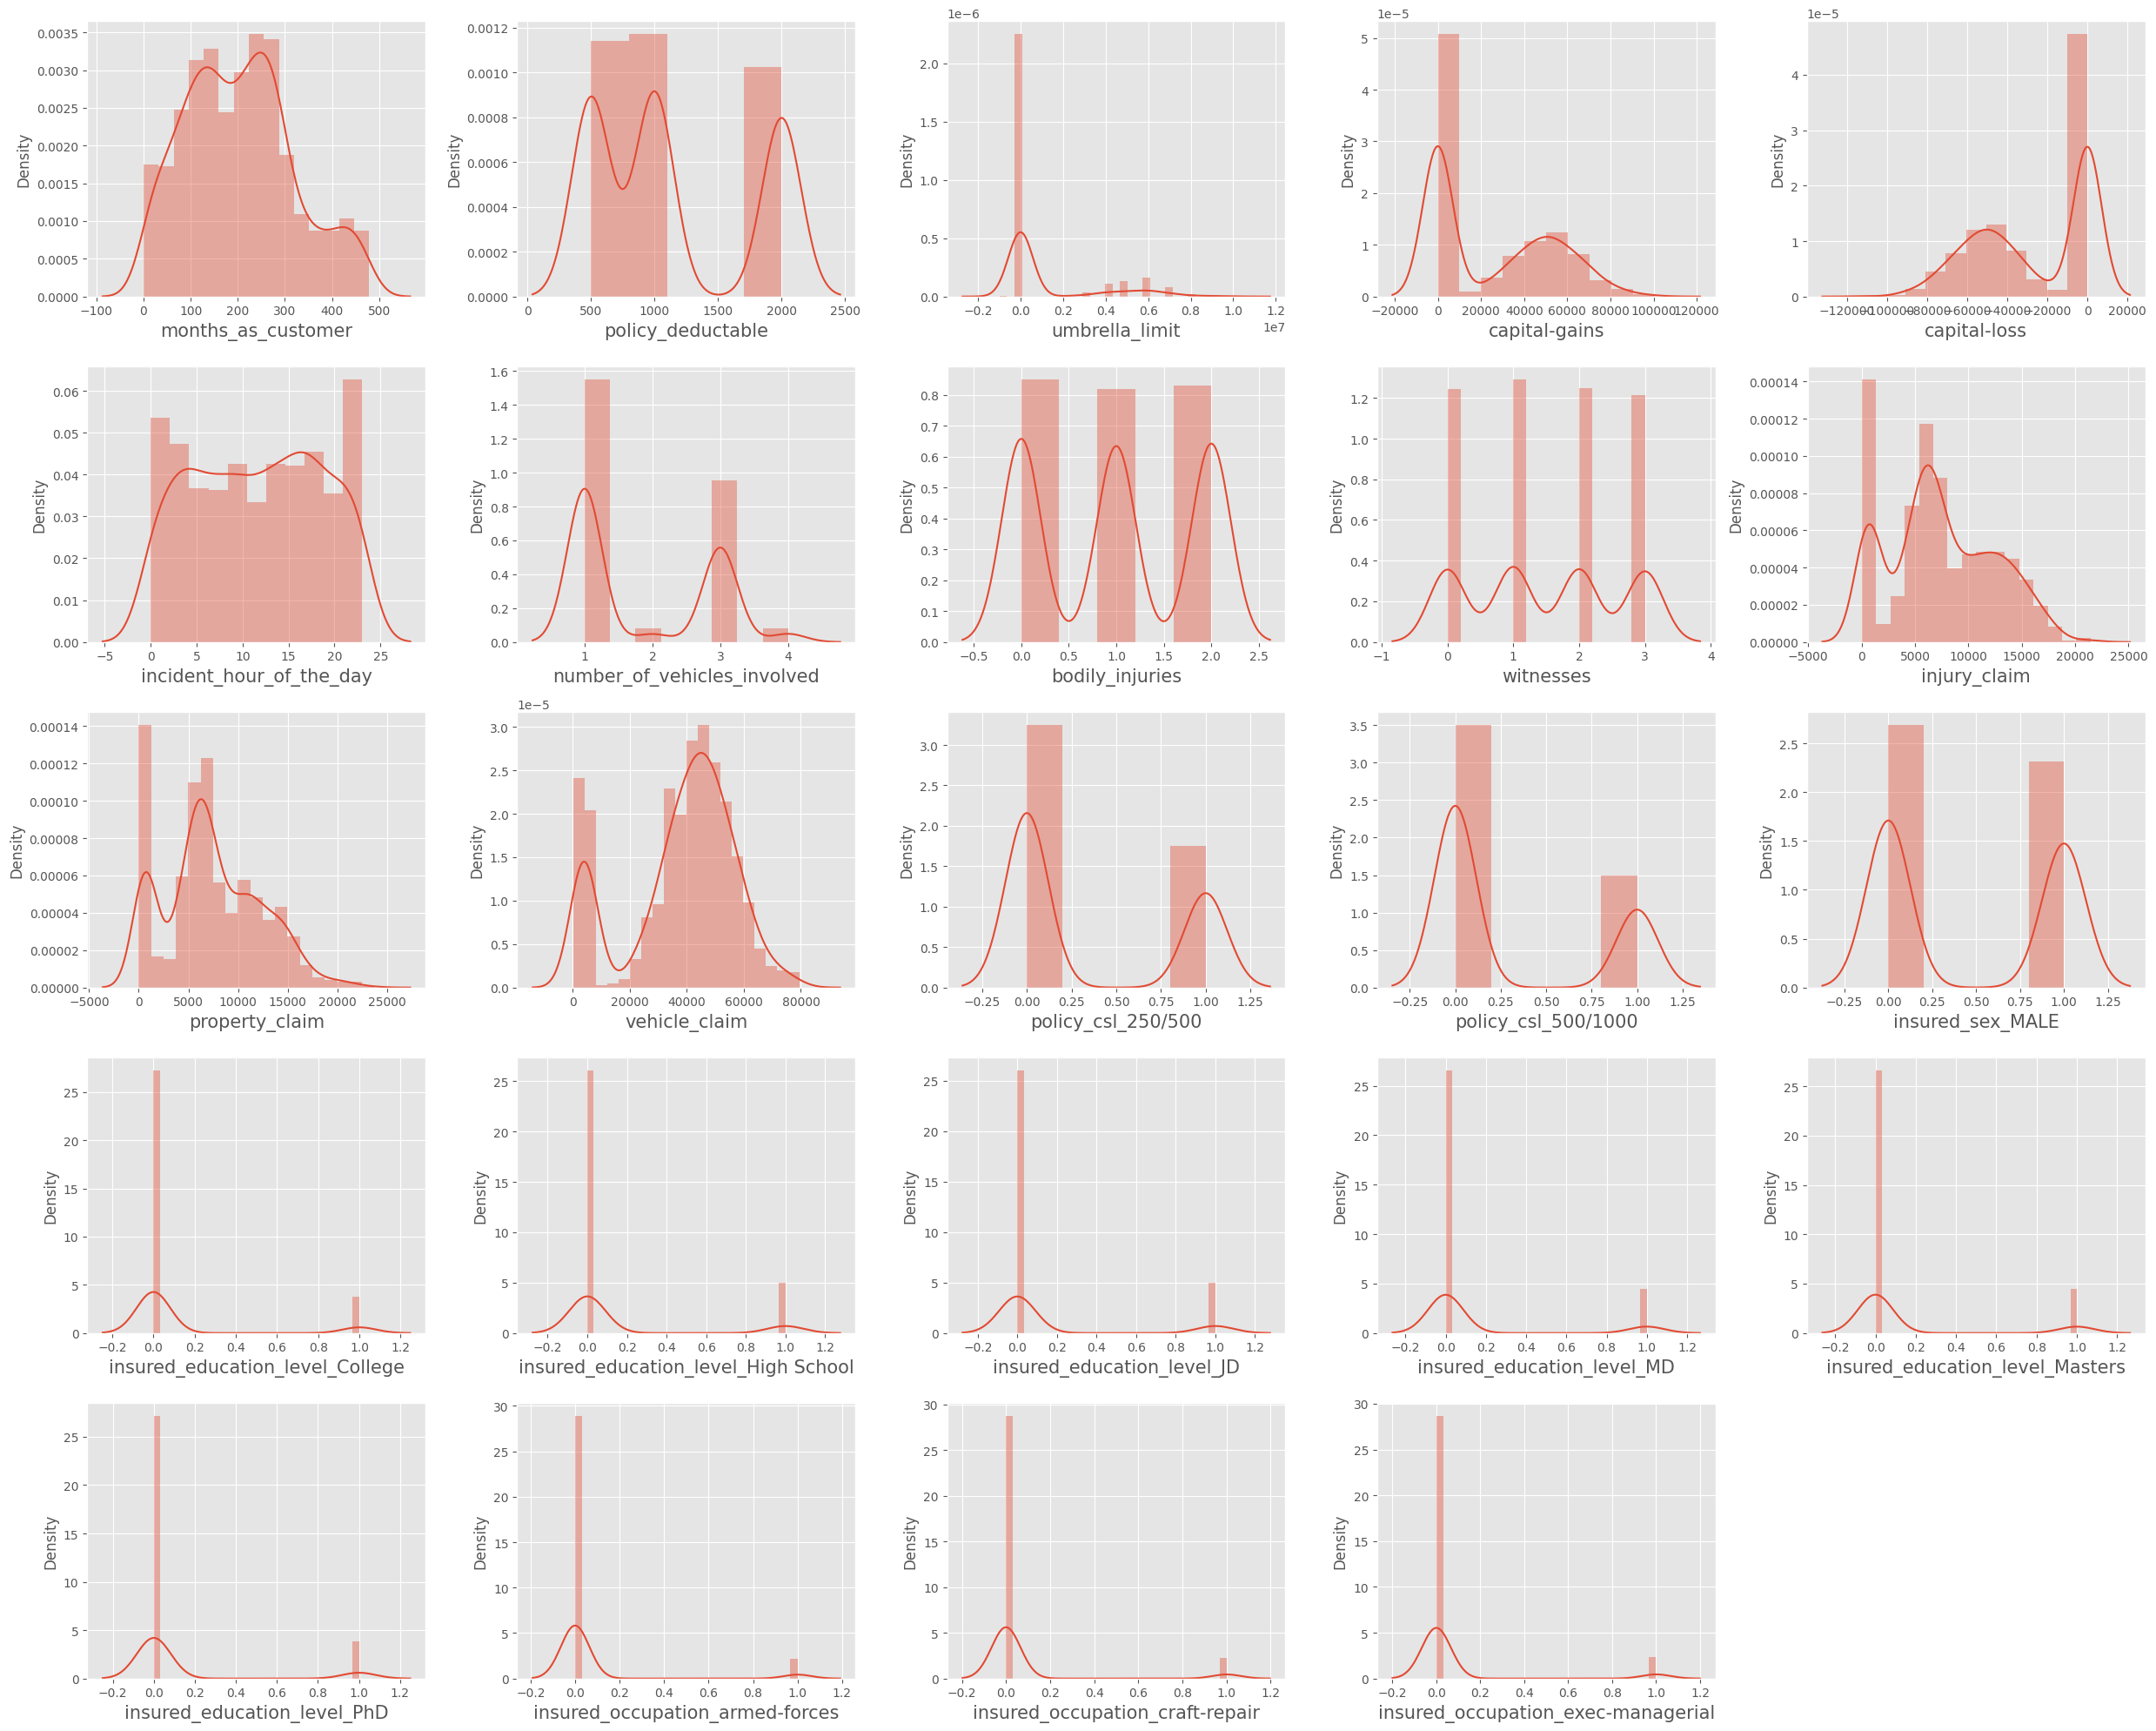

In [18]:
plt.figure(figsize = (25, 20))
plotnumber = 1

for col in X.columns:
    if plotnumber <= 24:
        ax = plt.subplot(5, 5, plotnumber)
        sns.distplot(X[col])
        plt.xlabel(col, fontsize = 15)
        
    plotnumber += 1
    
plt.tight_layout()
plt.show()

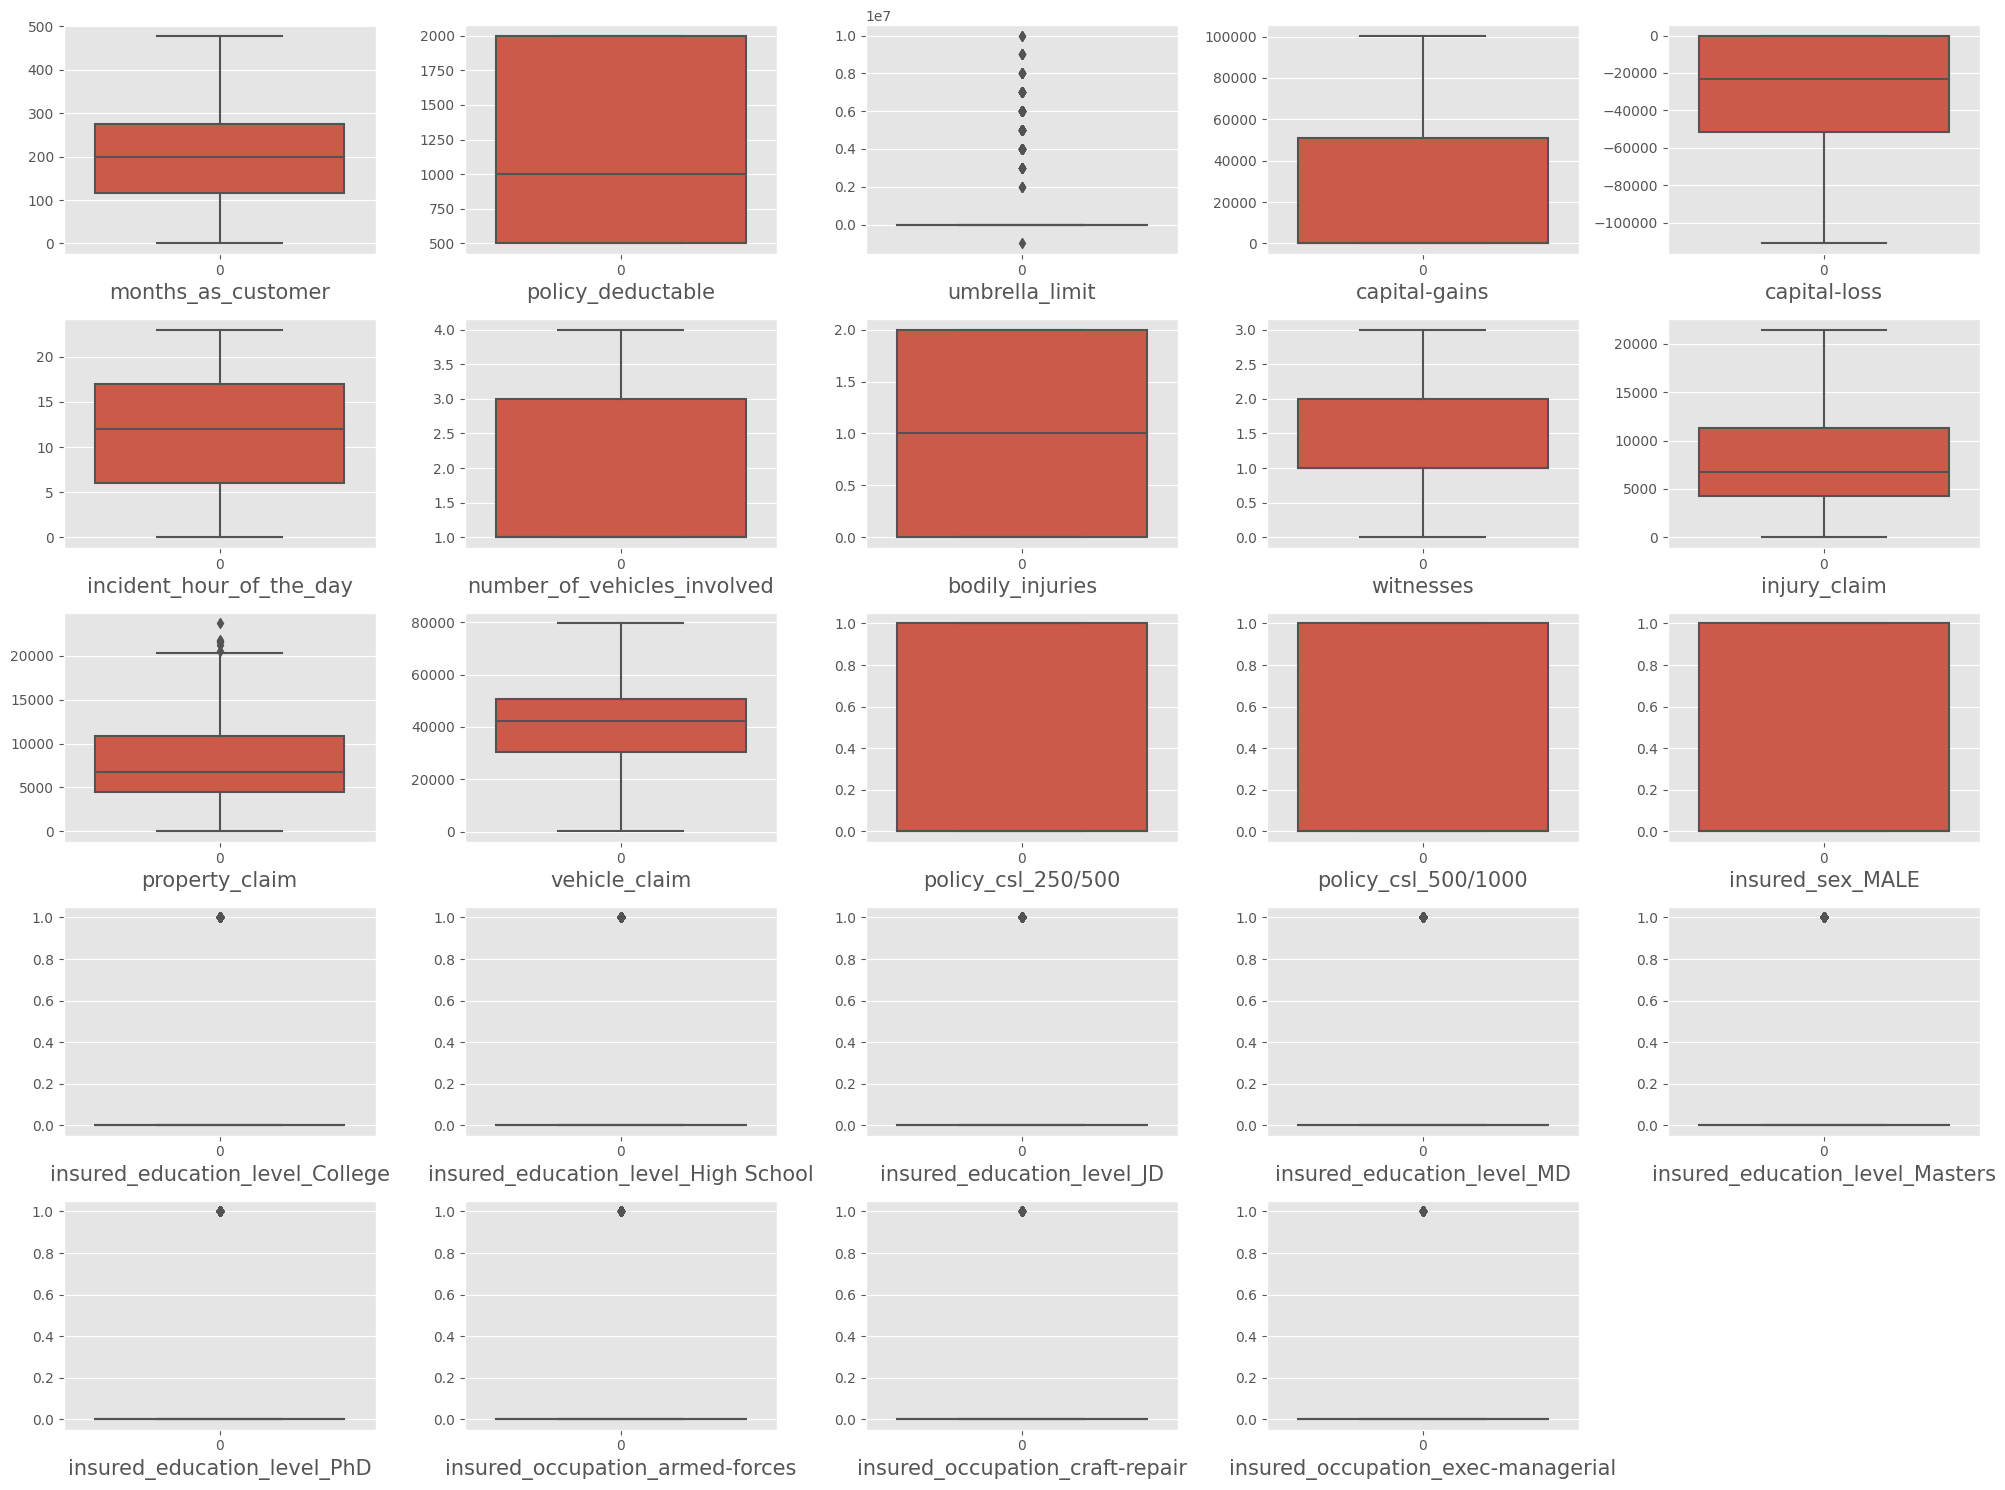

In [19]:
plt.figure(figsize = (20, 15))
plotnumber = 1

for col in X.columns:
    if plotnumber <= 24:
        ax = plt.subplot(5, 5, plotnumber)
        sns.boxplot(X[col])
        plt.xlabel(col, fontsize = 15)
    
    plotnumber += 1
plt.tight_layout()
plt.show()

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

In [21]:
num_df = X_train[['months_as_customer', 'policy_deductable', 'umbrella_limit',
       'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'injury_claim', 'property_claim',
       'vehicle_claim']]

In [22]:
# Scaling the numeric values in the dataset

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(num_df)

In [23]:
scaled_num_df = pd.DataFrame(data = scaled_data, columns = num_df.columns, index = X_train.index)
scaled_num_df.head()

,months_as_customer,policy_deductable,umbrella_limit,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,injury_claim,property_claim,vehicle_claim
214,-0.536710,1.443593,1.676609,-0.901053,0.972568,-0.077762,-0.825717,0.003247,1.368501,-0.123649,1.293728,1.253177
942,-0.832595,1.443593,2.108280,0.997798,-0.965164,-0.939653,-0.825717,0.003247,1.368501,-1.361759,-1.354705,-1.857483
899,-0.667248,-1.017077,-0.481745,1.749427,0.972568,-0.508707,-0.825717,0.003247,1.368501,-1.425729,-1.321547,-1.827599
72,-0.040670,-0.196854,-0.481745,-0.901053,0.972568,-0.221410,-0.825717,0.003247,0.459399,-0.901595,-1.516346,-0.557506
685,1.134164,-1.017077,-0.481745,0.059162,-0.711796,-0.652356,-0.825717,1.220715,-1.358804,-0.490955,0.555980,-0.135387


In [24]:
X_train.drop(columns = scaled_num_df.columns, inplace = True)


In [25]:
X_train = pd.concat([scaled_num_df, X_train], axis = 1)


In [28]:
X_train.head()

,months_as_customer,policy_deductable,umbrella_limit,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,injury_claim,...,collision_type_Side Collision,incident_severity_Minor Damage,incident_severity_Total Loss,incident_severity_Trivial Damage,authorities_contacted_Fire,authorities_contacted_None,authorities_contacted_Other,authorities_contacted_Police,property_damage_YES,police_report_available_YES
214,-0.536710,1.443593,1.676609,-0.901053,0.972568,-0.077762,-0.825717,0.003247,1.368501,-0.123649,...,1,0,1,0,0,0,1,0,1,0
942,-0.832595,1.443593,2.108280,0.997798,-0.965164,-0.939653,-0.825717,0.003247,1.368501,-1.361759,...,0,1,0,0,0,1,0,0,0,0
899,-0.667248,-1.017077,-0.481745,1.749427,0.972568,-0.508707,-0.825717,0.003247,1.368501,-1.425729,...,0,1,0,0,0,1,0,0,1,0
72,-0.040670,-0.196854,-0.481745,-0.901053,0.972568,-0.221410,-0.825717,0.003247,0.459399,-0.901595,...,0,1,0,0,0,0,0,0,0,0
685,1.134164,-1.017077,-0.481745,0.059162,-0.711796,-0.652356,-0.825717,1.220715,-1.358804,-0.490955,...,0,0,0,0,1,0,0,0,0,0


In [26]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)

In [27]:
# accuracy_score, confusion_matrix and classification_report

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

svc_train_acc = accuracy_score(y_train, svc.predict(X_train))
svc_test_acc = accuracy_score(y_test, y_pred)

print(f"Training accuracy of Support Vector Classifier is : {svc_train_acc}")
print(f"Test accuracy of Support Vector Classifier is : {svc_test_acc}")

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Training accuracy of Support Vector Classifier is : 0.8613333333333333
Test accuracy of Support Vector Classifier is : 0.788
[[197   0]
 [ 53   0]]
              precision    recall  f1-score   support

           N       0.79      1.00      0.88       197
           Y       0.00      0.00      0.00        53

    accuracy                           0.79       250
   macro avg       0.39      0.50      0.44       250
weighted avg       0.62      0.79      0.69       250

